# 10 - MiniSD + MiniFLUX (MNIST)

> 配套笔记：[01_05 Diffusion（下）](https://github.com/Zoey-Cheng/MLSys-Learning-Notes/blob/main/notes/01_模型基础/01_05_Diffusion进阶.md) ｜ 知乎：*WIP*

增量链（一次只加一层）：

| Section | 实现什么 | 增量 |
| --- | --- | --- |
| §1 基座 | 07 BasicDDIM 组件原样搬运 | 无 |
| §2 **MiniSD** | 文生图 = 基座 + **① latent（tiny AE）② 条件（类别标签）③ CFG**；主干 U-Net 只 call | doc §2 |
| §3 **MiniFLUX** | = MiniSD **换三件：target ε→v、采样 DDIM→Euler、主干换手写双流 MMDiT**；①②③继承 | doc §3+§4 |

注释约定：`# ←` = 相对基线的新增/改动行；无箭头 = 照搬。MMDiT 主干全新手写，不标 diff。

**跑什么**：MNIST 按类别标签条件生成（"文本" = 数字 0–9，toy 化妥协见 doc §7）。**验证点**：

1. AE 重建图上下两排肉眼一致 → 增量① latent 压缩可用
2. 采样网格每行按 0–9 顺排出对应数字 → 增量② 条件注入生效；w 从 0 → 7.5 数字从随机变对齐 → 增量③ CFG 生效
3. MiniFLUX 20 步出图、8 步不明显变差 → v-prediction + Euler 生效（直线路径少步也稳）


## 0. 环境

依赖只用 PyTorch + torchvision + matplotlib。

In [1]:
!nvidia-smi 2>/dev/null | head -10 || echo 'no GPU; CPU 也能跑，只是慢一点'

Sun Jul 12 23:33:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |


In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1),     # [0, 1] -> [-1, 1]
])
ds = MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(ds, batch_size=128, shuffle=True, num_workers=2, drop_last=True)
print(f'#samples: {len(ds)}, #batches/epoch: {len(loader)}')

def show(samples, title=''):
    """samples: [N, 1, H, W] in [-1, 1]."""
    samples = samples.clamp(-1, 1).cpu().numpy()
    samples = (samples + 1) / 2
    n = samples.shape[0]
    cols = min(n, 10)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.1, rows * 1.1))
    axes = axes.flatten() if rows > 1 else ([axes] if cols == 1 else axes)
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(samples[i, 0], cmap='gray')
        ax.axis('off')
    if title: fig.suptitle(title)
    plt.tight_layout()
    plt.show()

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.56MB/s]

#samples: 60000, #batches/epoch: 468


## 1. 基座：07 BasicDDIM 组件（原样搬运，零新增）

schedule / `extract` / `TimeEmbedding` 三件，一行未改。schedule 只有 MiniSD 用——MiniFLUX 在 §3 换成连续 t，离散 schedule 整个丢掉。

In [4]:
T = 1000
betas  = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
abar   = torch.cumprod(alphas, dim=0)

def extract(a, t, shape):
    out = a.gather(-1, t)
    return out.view(shape[0], *([1] * (len(shape) - 1)))

class TimeEmbedding(nn.Module):
    """Sinusoidal embedding（同 07）。输入支持 float（MiniFLUX 的连续 t 也用它）。"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args  = t[:, None].float() * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)

## 2. MiniSD = 基座 + 三增量（doc §2）

**增量① latent（doc §2.1）**：tiny AE（代替 SD 的 KL-VAE），像素 `28×28×1` ↔ latent `14×14×4`，MSE 训 2 epoch 后**冻结**；`LATENT_STD` 把 latent 缩放到 std ≈ 1（SD 那个 0.18215 缩放因子的同款作用）。

AE epoch 1: recon loss = 0.0604
AE epoch 2: recon loss = 0.0060
LATENT_STD = 1.042


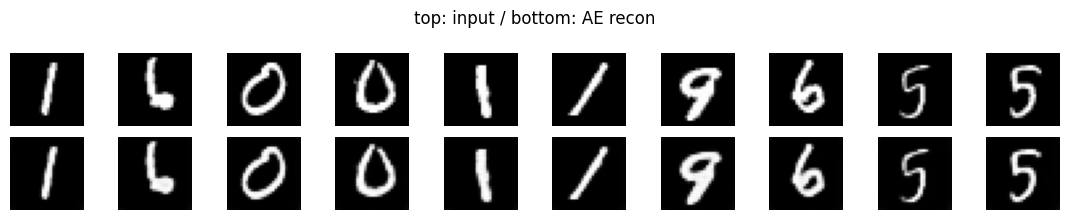

In [5]:
class TinyAE(nn.Module):
    """像素 28x28x1 <-> latent 14x14x4。普通 AE（MSE 重建），代替 SD 的 KL-VAE。"""
    def __init__(self, latent_ch=4):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),   # 28 -> 14
            nn.SiLU(),
            nn.Conv2d(32, latent_ch, 3, padding=1),
        )
        self.dec = nn.Sequential(
            nn.Conv2d(latent_ch, 32, 3, padding=1),
            nn.SiLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),  # 14 -> 28
            nn.Tanh(),
        )

    def forward(self, x):
        return self.dec(self.enc(x))

ae = TinyAE().to(device)
opt = torch.optim.AdamW(ae.parameters(), lr=1e-3)
for epoch in range(2):
    running = 0.0
    for x, _ in loader:
        x = x.to(device)
        loss = F.mse_loss(ae(x), x)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item()
    print(f'AE epoch {epoch+1}: recon loss = {running/len(loader):.4f}')

ae.requires_grad_(False).eval()

# latent 归一化系数（SD 的 0.18215 同款作用）
with torch.no_grad():
    x, _ = next(iter(loader))
    LATENT_STD = ae.enc(x.to(device)).std().item()
print(f'LATENT_STD = {LATENT_STD:.3f}')

@torch.no_grad()
def encode_norm(x):
    return ae.enc(x) / LATENT_STD

@torch.no_grad()
def decode_norm(z):
    return ae.dec(z * LATENT_STD)

# 重建 sanity check：上排原图，下排 AE 重建
x, _ = next(iter(loader))
x = x[:10].to(device)
show(torch.cat([x, decode_norm(encode_norm(x))]), title='top: input / bottom: AE recon')

**增量② 条件（doc §2.2）+ ③ CFG（doc §2.3）**：类别标签当"文本"，text encoder 退化成 `nn.Embedding` 查表；**index 10 = null 条件**，CFG 训练时 10% dropout 换成它。

In [6]:
NUM_CLASSES = 10
NULL_ID = 10          # CFG 的空条件

def cfg_dropout(y, p=0.1):
    """训练时 10% 概率把标签换成 null（doc §2.3）。"""
    drop = torch.rand(y.shape, device=y.device) < p
    return torch.where(drop, torch.full_like(y, NULL_ID), y)

**主干（只 call 不展开）**：`CondUNet` = 07 的 toy U-Net 加一路条件 c，适配 latent 尺寸。

> 真 SD 的 c 是 77 个 token 的序列所以要 cross-attn；toy 的 c 只有 1 个 token，cross-attn 的 softmax 单键恒为 1，**退化成加法注入**——所以 c 走 t 同款注入，不算偷工减料。

In [7]:
class CondResBlock(nn.Module):
    """07 的 ResBlock + 第二路条件注入（c 与 t 同款：投影后加到 channel 上）。"""
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.norm1  = nn.GroupNorm(8, in_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2  = nn.GroupNorm(8, out_ch)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(emb_dim, out_ch)
        self.c_proj = nn.Linear(emb_dim, out_ch)                 # ← 新增: 条件 c 的投影（t_proj 是 07 原有）
        self.skip   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb, c_emb):                          # ← 多接一路 c_emb
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None]     # 注入 t（同 07）
        h = h + self.c_proj(F.silu(c_emb))[:, :, None, None]     # ← 新增: 注入 c，方式和 t 相同
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class CondUNet(nn.Module):
    """07 的 toy U-Net 加一路条件。latent 14x14x4，一级下采样 + 双 mid（base=64，~1.1M，对齐 07 量级）。"""
    def __init__(self, ch=4, base=64, emb_dim=128):
        super().__init__()
        self.t_mlp = nn.Sequential(
            TimeEmbedding(emb_dim),
            nn.Linear(emb_dim, emb_dim), nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        self.label_emb = nn.Embedding(NUM_CLASSES + 1, emb_dim)   # ← 新增: "text encoder"，+1 = CFG null
        self.in_conv = nn.Conv2d(ch, base, 3, padding=1)
        self.down1   = CondResBlock(base,     base * 2, emb_dim)  # 14 -> 7
        self.mid1    = CondResBlock(base * 2, base * 2, emb_dim)
        self.mid2    = CondResBlock(base * 2, base * 2, emb_dim)
        self.up1     = CondResBlock(base * 2 + base, base, emb_dim)  # 7 -> 14
        self.out_norm = nn.GroupNorm(8, base)
        self.out_conv = nn.Conv2d(base, ch, 3, padding=1)

    def forward(self, z, t, y):                                 # ← 多接一个 y（类别条件）
        t_emb = self.t_mlp(t)
        c_emb = self.label_emb(y)                               # ← 新增: 条件 embedding
        h0 = self.in_conv(z)                                        # 14x14
        h1 = self.down1(F.avg_pool2d(h0, 2), t_emb, c_emb)          # 7x7
        m  = self.mid1(h1, t_emb, c_emb)                            # 7x7
        m  = self.mid2(m, t_emb, c_emb)
        u1 = self.up1(torch.cat([F.interpolate(m, scale_factor=2), h0], dim=1), t_emb, c_emb)
        return self.out_conv(F.silu(self.out_norm(u1)))

sd_model = CondUNet().to(device)
print(f'MiniSD #params: {sum(p.numel() for p in sd_model.parameters())/1e6:.2f} M')

MiniSD #params: 1.14 M


In [8]:
def train_step_sd(x, y, model):
    """doc §2.5：BasicDDIM 训练 + 三增量（latent / 条件 / CFG dropout）。"""
    z0 = encode_norm(x)                          # ← latent: 像素 -> latent（AE 冻结，doc §2.1）
    y  = cfg_dropout(y)                          # ← CFG: 10% 换 null
    B  = z0.size(0)
    t   = torch.randint(0, T, (B,), device=z0.device)
    eps = torch.randn_like(z0)
    a   = extract(abar, t, z0.shape)
    zt  = a.sqrt() * z0 + (1 - a).sqrt() * eps   # 加噪公式同 07，只是 x -> z
    eps_pred = model(zt, t, y)                   # ← 多接一个 y
    return F.mse_loss(eps_pred, eps)

In [9]:
%%time
EPOCHS = 10
opt = torch.optim.AdamW(sd_model.parameters(), lr=2e-4)
sd_model.train()
for epoch in range(EPOCHS):
    running = 0.0
    for x, y in loader:
        loss = train_step_sd(x.to(device), y.to(device), sd_model)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item()
    print(f'epoch {epoch+1:02d}: avg loss = {running/len(loader):.4f}')

epoch 01: avg loss = 0.1480
epoch 02: avg loss = 0.0591
epoch 03: avg loss = 0.0485
epoch 04: avg loss = 0.0431
epoch 05: avg loss = 0.0407
epoch 06: avg loss = 0.0374
epoch 07: avg loss = 0.0358
epoch 08: avg loss = 0.0350
epoch 09: avg loss = 0.0333
epoch 10: avg loss = 0.0332
CPU times: user 1min 27s, sys: 2.01 s, total: 1min 29s
Wall time: 2min 17s


In [10]:
@torch.no_grad()
def ddim_sample_cfg(model, y, steps=50, eta=0.0, w=3.0):
    """07 的 ddim_sample + CFG 双前向外推（doc §2.3）。在 latent 空间走，最后 decode。"""
    model.eval()
    B = y.size(0)
    y_null = torch.full_like(y, NULL_ID)             # ← CFG: 无条件分支的 null 标签
    seq = torch.linspace(T - 1, 0, steps, device=device).long()
    z = torch.randn(B, 4, 14, 14, device=device)     # 同 07，只是起点在 latent 空间

    for i in range(len(seq)):
        t  = seq[i].item()
        tp = seq[i + 1].item() if i + 1 < len(seq) else -1
        tb = torch.full((B,), t, device=device, dtype=torch.long)

        eps_c  = model(z, tb, y)                     # ← 条件预测（多接 y）
        eps_un = model(z, tb, y_null)                # ← CFG: 无条件预测（多一次前向）
        eps    = eps_un + w * (eps_c - eps_un)       # ← CFG: 外推（doc §2.3 公式）

        a_t    = abar[t]
        a_prev = abar[tp] if tp >= 0 else torch.tensor(1.0, device=device)
        z0_pred = (z - (1 - a_t).sqrt() * eps) / a_t.sqrt()
        sigma   = eta * ((1 - a_prev) / (1 - a_t)).sqrt() * (1 - a_t / a_prev).sqrt()
        noise   = torch.randn_like(z) if eta > 0 and tp >= 0 else torch.zeros_like(z)
        z = a_prev.sqrt() * z0_pred + (1 - a_prev - sigma ** 2).clamp(min=0).sqrt() * eps + sigma * noise

    model.train()
    return decode_norm(z)                            # ← latent: latent -> 像素

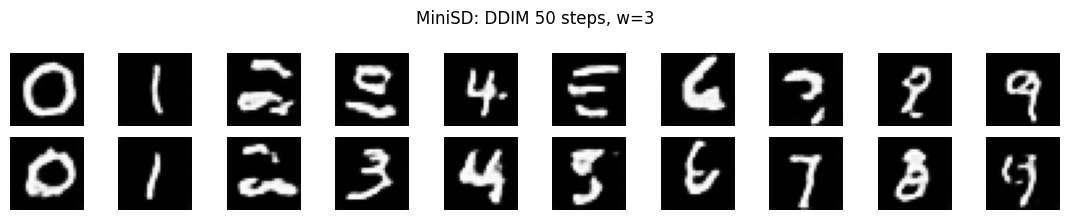

In [11]:
# 0-9 各生成两张
y = torch.arange(10, device=device).repeat(2)
show(ddim_sample_cfg(sd_model, y, steps=50, w=3.0), title='MiniSD: DDIM 50 steps, w=3')

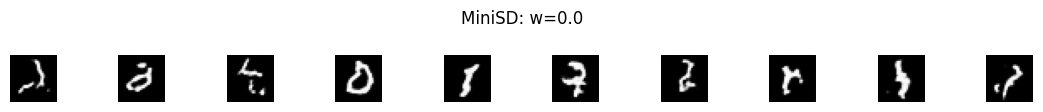

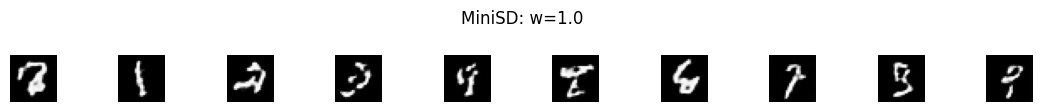

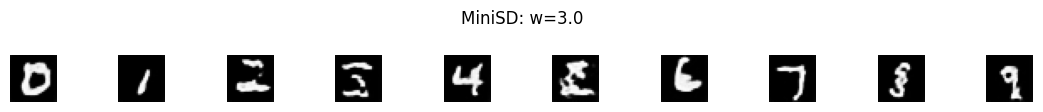

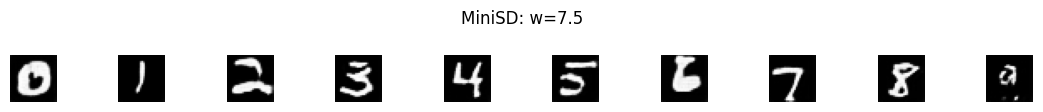

In [12]:
# CFG 强度对比：w=0 等价无条件，w 越大越贴标签（太大过饱和）
for w in [0.0, 1.0, 3.0, 7.5]:
    y = torch.arange(10, device=device)
    show(ddim_sample_cfg(sd_model, y, steps=50, w=w), title=f'MiniSD: w={w}')

## 3. MiniFLUX = MiniSD 换三件（doc §3 + §4）

增量①②③**原样继承**；换掉：训练 target（ε → v）、采样器（DDIM → Euler）、主干（CondUNet → **手写双流 MMDiT**）。

主干对照 doc §3 逐件搭：patchify / unpatchify（§3.1 入口/出口，`14×14×4` → 49 个 token + 2D sin-cos）、adaLN-Zero（§3.1，条件向量回归 6 组调制参数、零初始化起步恒等）、MMDiTBlock（§3.2，两套参数 + 一次无参联合 attention）。toy 文本序列长 1，「逐 token 拼接」和「pooled 进 adaLN」两路恰好是同一个向量。

In [13]:
def modulate(x, shift, scale):
    return x * (1 + scale) + shift

def sincos_2d(d, h, w):
    """2D sin-cos 位置编码：前一半维度编码行号，后一半编码列号。返回 [h*w, d]。"""
    def one_axis(d_half, pos):
        omega = torch.exp(-math.log(10000) * torch.arange(d_half // 2) / (d_half // 2))
        out = pos[:, None].float() * omega[None, :]
        return torch.cat([out.sin(), out.cos()], dim=1)          # [len, d_half]
    ys = one_axis(d // 2, torch.arange(h))                        # [h, d/2]
    xs = one_axis(d // 2, torch.arange(w))                        # [w, d/2]
    grid = torch.cat([
        ys[:, None, :].expand(h, w, d // 2),
        xs[None, :, :].expand(h, w, d // 2),
    ], dim=-1)
    return grid.reshape(h * w, d)

In [14]:
class StreamWeights(nn.Module):
    """MMDiT 一条流的全部带参组件（doc §3.2：带权重的每模态一套）。"""
    def __init__(self, d, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(d, elementwise_affine=False, eps=1e-6)  # 仿射交给 adaLN
        self.qkv   = nn.Linear(d, 3 * d)
        self.proj  = nn.Linear(d, d)                  # attention 输出投影 W_o
        self.norm2 = nn.LayerNorm(d, elementwise_affine=False, eps=1e-6)
        self.mlp   = nn.Sequential(nn.Linear(d, int(d * mlp_ratio)), nn.GELU(),
                                   nn.Linear(int(d * mlp_ratio), d))
        # adaLN-Zero：从条件向量回归 6 组调制参数，零初始化
        self.adaLN = nn.Sequential(nn.SiLU(), nn.Linear(d, 6 * d))
        nn.init.zeros_(self.adaLN[-1].weight)
        nn.init.zeros_(self.adaLN[-1].bias)


class MMDiTBlock(nn.Module):
    """双流 block：两套参数，唯一合并点是中间那次无参数的联合 attention。"""
    def __init__(self, d, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.img = StreamWeights(d)
        self.txt = StreamWeights(d)

    def _pre(self, s, x, cond):
        """一条流的前半：adaLN 调制 + QKV 投影（分开的部分）。"""
        mods = s.adaLN(cond)[:, None, :].chunk(6, dim=-1)   # 6 x [B, 1, d]
        sh1, sc1, g1, sh2, sc2, g2 = mods
        h = modulate(s.norm1(x), sh1, sc1)
        q, k, v = s.qkv(h).chunk(3, dim=-1)
        return (q, k, v), (g1, sh2, sc2, g2)

    def _post(self, s, x, attn_out, gates):
        """一条流的后半：输出投影 + 门控残差 + FFN（分开的部分）。"""
        g1, sh2, sc2, g2 = gates
        x = x + g1 * s.proj(attn_out)
        x = x + g2 * s.mlp(modulate(s.norm2(x), sh2, sc2))
        return x

    def forward(self, img, txt, cond):
        (qi, ki, vi), gi = self._pre(self.img, img, cond)
        (qt, kt, vt), gt = self._pre(self.txt, txt, cond)

        # 唯一合并点：拼接两路序列，做一次联合 attention（softmax(QK^T)V 无参数）
        q = torch.cat([qt, qi], dim=1)
        k = torch.cat([kt, ki], dim=1)
        v = torch.cat([vt, vi], dim=1)
        B, N, d = q.shape
        hd = d // self.n_heads
        q, k, v = (u.view(B, N, self.n_heads, hd).transpose(1, 2) for u in (q, k, v))
        out = F.scaled_dot_product_attention(q, k, v)
        out = out.transpose(1, 2).reshape(B, N, d)

        # 切回两路，各走各的输出投影 + FFN
        Lt = txt.size(1)
        txt = self._post(self.txt, txt, out[:, :Lt], gt)
        img = self._post(self.img, img, out[:, Lt:], gi)
        return img, txt

In [15]:
class MiniFlux(nn.Module):
    """patchify -> N x MMDiTBlock -> final layer -> unpatchify。预测 v。"""
    def __init__(self, ch=4, size=14, patch=2, d=128, n_heads=4, depth=4):
        super().__init__()
        self.patch, self.ch = patch, ch
        self.hw = size // patch                               # 7
        self.patchify = nn.Conv2d(ch, d, kernel_size=patch, stride=patch)
        self.register_buffer('pos', sincos_2d(d, self.hw, self.hw)[None])  # [1, 49, d]

        self.t_mlp = nn.Sequential(
            TimeEmbedding(d), nn.Linear(d, d), nn.SiLU(), nn.Linear(d, d))
        self.label_emb = nn.Embedding(NUM_CLASSES + 1, d)     # 文本流的 token，也进 adaLN

        self.blocks = nn.ModuleList([MMDiTBlock(d, n_heads) for _ in range(depth)])

        # final layer：adaLN 调制 + 零初始化投影回 patch
        self.final_norm  = nn.LayerNorm(d, elementwise_affine=False, eps=1e-6)
        self.final_adaLN = nn.Sequential(nn.SiLU(), nn.Linear(d, 2 * d))
        self.final_proj  = nn.Linear(d, patch * patch * ch)
        nn.init.zeros_(self.final_adaLN[-1].weight)
        nn.init.zeros_(self.final_adaLN[-1].bias)
        nn.init.zeros_(self.final_proj.weight)
        nn.init.zeros_(self.final_proj.bias)

    def unpatchify(self, x):
        B, N, _ = x.shape
        p, c, hw = self.patch, self.ch, self.hw
        x = x.view(B, hw, hw, p, p, c)
        x = x.permute(0, 5, 1, 3, 2, 4)                       # [B, c, hw, p, hw, p]
        return x.reshape(B, c, hw * p, hw * p)

    def forward(self, z, t, y):
        """z: [B,4,14,14]; t: [B] float in [0,1]; y: [B] 标签（10 = null）。"""
        img = self.patchify(z).flatten(2).transpose(1, 2) + self.pos    # [B, 49, d]
        txt = self.label_emb(y)[:, None, :]                             # [B, 1, d] 文本流
        cond = self.t_mlp(t * 1000) + self.label_emb(y)                 # adaLN 条件向量

        for blk in self.blocks:
            img, txt = blk(img, txt, cond)

        sh, sc = self.final_adaLN(cond)[:, None, :].chunk(2, dim=-1)
        out = self.final_proj(modulate(self.final_norm(img), sh, sc))
        return self.unpatchify(out)                                     # v̂: [B,4,14,14]

flux_model = MiniFlux().to(device)
print(f'MiniFLUX #params: {sum(p.numel() for p in flux_model.parameters())/1e6:.2f} M')

MiniFLUX #params: 2.45 M


训练 / 采样（doc §4.2）：diff 只有 `# ← FM` 标出的三处。

In [16]:
def train_step_fm(x, y, model):
    z0 = encode_norm(x)
    y  = cfg_dropout(y)
    B  = z0.size(0)
    t  = torch.sigmoid(torch.randn(B, device=z0.device))   # ← FM: logit-normal，中间时刻更密
    t_bc = t.view(B, 1, 1, 1)
    eps = torch.randn_like(z0)
    zt  = (1 - t_bc) * z0 + t_bc * eps                     # ← FM: 直线插值
    v_gt   = eps - z0                                      # ← FM: target 换成速度 v
    v_pred = model(zt, t, y)
    return F.mse_loss(v_pred, v_gt)

In [17]:
%%time
EPOCHS = 10
opt = torch.optim.AdamW(flux_model.parameters(), lr=2e-4)
flux_model.train()
for epoch in range(EPOCHS):
    running = 0.0
    for x, y in loader:
        loss = train_step_fm(x.to(device), y.to(device), flux_model)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item()
    print(f'epoch {epoch+1:02d}: avg loss = {running/len(loader):.4f}')

epoch 01: avg loss = 0.6234
epoch 02: avg loss = 0.3508
epoch 03: avg loss = 0.2772
epoch 04: avg loss = 0.2272
epoch 05: avg loss = 0.2068
epoch 06: avg loss = 0.1958
epoch 07: avg loss = 0.1883
epoch 08: avg loss = 0.1838
epoch 09: avg loss = 0.1799
epoch 10: avg loss = 0.1759
CPU times: user 2min 40s, sys: 2.56 s, total: 2min 43s
Wall time: 3min 8s


In [18]:
@torch.no_grad()
def euler_sample_cfg(model, y, steps=20, w=3.0):
    """Euler 解 ODE：从 t=1 纯噪出发，每步沿 CFG 后的速度走 dt（doc §4.2）。"""
    model.eval()
    B = y.size(0)
    y_null = torch.full_like(y, NULL_ID)
    z = torch.randn(B, 4, 14, 14, device=device)
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((B,), 1.0 - i * dt, device=device)
        v_c  = model(z, t, y)
        v_un = model(z, t, y_null)
        v    = v_un + w * (v_c - v_un)          # CFG 公式和 MiniSD 一字不差
        z    = z - v * dt                       # ← FM: dz/dt = v，逆着走
    model.train()
    return decode_norm(z)

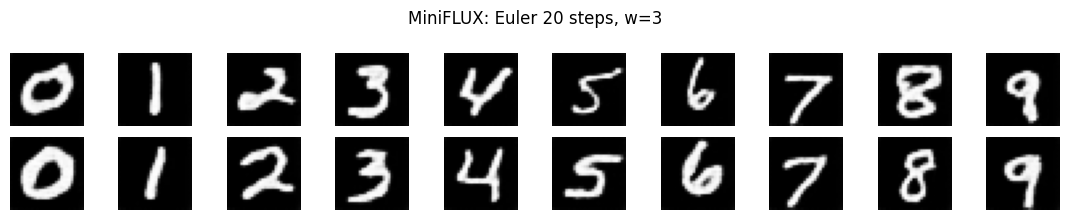

In [19]:
y = torch.arange(10, device=device).repeat(2)
show(euler_sample_cfg(flux_model, y, steps=20, w=3.0), title='MiniFLUX: Euler 20 steps, w=3')

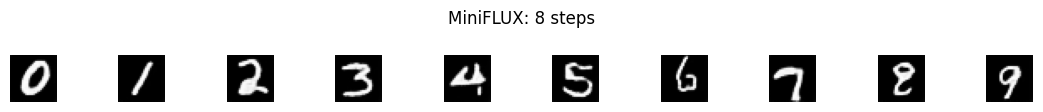

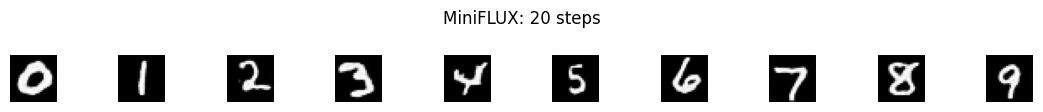

In [20]:
# 直线路径对少步数更稳：8 步 vs 20 步
for steps in [8, 20]:
    y = torch.arange(10, device=device)
    show(euler_sample_cfg(flux_model, y, steps=steps, w=3.0), title=f'MiniFLUX: {steps} steps')

---

收尾对照（doc §4 的对照记忆表落到代码）：

增量链收尾（对照 doc）：

| | 基座 07 BasicDDIM | MiniSD = 基座 + 三增量 | MiniFLUX = MiniSD 换三件 |
| --- | --- | --- | --- |
| 空间 | 像素 | **+ tiny AE latent（①）** | 继承 ① |
| 条件 | 无 | **+ 类别标签（②）+ CFG（③）** | 继承 ②③ |
| 训练 target | ε（离散 t） | ε（离散 t） | **v = ε − z₀（连续 t，logit-normal）** |
| 采样 | DDIM 反解 | DDIM 反解 + CFG | **Euler 解 ODE** + CFG |
| 主干 | toy U-Net | CondUNet（U-Net + c，只 call） | **手写双流 MMDiT** |

每一列相对上一列，加粗处就是全部改动——「一次只加一层」和 doc §2 → §3/§4 的推进完全对应。